<div align="center">

<h1>TP2 - Projeto de Bloco: Análise e Segurança de Agentes de IA</h1>

</div>

##### Professor: Tiago Xavier;
###### Estudantes - E-mails: 
###### Caio Ribeiro Pereira - caio.rpereira@al.infnet.edu.br;
###### Paulo Henrique de Paula Dias - paulo.dias@al.infnet.edu.br;
###### Pedro Marchiori de Araújo - pedro.maraujo@al.infnet.edu.br.

### Instruções

**Dataset**

O dataset para o trabalho é 'Customer Support Ticket Dataset' disponível no kaggle no link:

DatasetLink: https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data

#### **Tarefas do TP2**
##### Instruções realizadas nesse arquivo

Implemente o EDA completo sobre o conjunto de dados Customer Support Ticket Dataset considerando as variáveis numéricas, categóricas e textuais. Formule pelo menos duas hipóteses e realize um teste de hipótese formal (t-test ou Mann-Whitney) para cada hipótese formulada. O EDA completo deve conter as seguintes etapas:

1.1. Compreensão do problema e do dataset
1.2. Inspeção inicial
1.3. Verificação da qualidade dos dados
1.4. Limpeza e preparação dos dados
1.5. Análise Univariada
1.6. Análise Multivariada
1.7. Identificação de Outliers e Anomalias
1.8. Documentação do EDA e conclusões

> Este notebook parte do EDA inicial feito no TP1 (etapas 1.1 a 1.5) e o estende com testes de hipótese formais e as novas etapas 1.6 a 1.8.

## 1.1. Compreensão do problema e do dataset

O *dataset* "*Customer Support Ticket Dataset*" ([Link](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data)), trata-se de uma base de dados pública disponível na plataforma Kaggle. Licenciado sob a **CC0: Public Domain** conforme informado na página oficial do dataset. Essa licença permite a utilização, modificação e redistribuição do conteúdo sem necessidade de solicitar autorização adicional ao autor. O *dataset* é composto por tickets de suporte ao cliente para problemas relacionados a diversos produtos tecnológicos, como:
* Problemas com Hardware;
* *Bugs* em Software;
* Problemas de Conectividade;
* Problemas de Acesso a Plataformas;
* Perda de Dados;
* Entre outros serviços.

A base de dados é composta pelas seguintes colunas:

- Ticket ID: Identificador único.
- Customer Name: Nome do cliente.
- Customer Email: Email do cliente (Alguns estão dispostos como - @example.com intencionalmente para privacidade).
- Customer Age: Idade do cliente.
- Customer Gender: Gênero do cliente.
- Product Purchased: O produto comprado pelo cliente.
- Date of Purchase: Data de compra do produto.
- Ticket Type: Classificação do ticket (Exemplo: *technical issue*, *billing inquiry*, *product inquiry*).
- Ticket Subject: O tópico/contexto do ticket.
- Ticket Description: Descrição do motivo da abertura do ticket (variável textual).
- Ticket Status: Status do ticket (Exemplo: *open*, *closed*, *pending customer response*).
- Resolution: A solução dada para tickets fechados.
- Ticket Priority: Nível de prioridade dado ao ticket (Exemplo: *low*, *medium*, *high*, *critical*).
- Ticket Channel: O canal de captura do ticket (Exemplo: *email*, *phone*, *chat*, *social media*).
- First Response Time: O tempo da primeira resposta ao cliente.
- Time to Resolution: Tempo de resolução completa do ticket.
- Customer Satisfaction Rating: Nível de satisfação do cliente entre 1 e 5.

Este *dataset* foi escolhido como base devido a sua variabilidade e complexidade, permitindo análise abrangente de dados de suporte ao cliente, combinando variáveis numéricas (idade, satisfação, tempos), categóricas (tipo, prioridade, canal) e textuais (descrição do ticket). Essa combinação é essencial para a construção de um sistema de IA que possa não apenas classificar a intenção do cliente a partir do texto, mas também considerar variáveis estruturadas do atendimento.

In [1]:
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

cs_df = pd.read_csv("../data/customer_support_tickets.csv")
cs_df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


*Dataset* é composto de 8469 linhas e 17 colunas, contendo informações sobre tickets de suporte ao cliente em relação à diversos produtos tecnológicos. Além das perguntas exploratórias já levantadas no TP1 (faixa etária, gênero, produto, canal, tipo e prioridade de ticket com maior dificuldade de resolução), este TP2 se propõe a responder de forma estatisticamente formal:

- O tempo de resolução realmente difere entre tickets de prioridades diferentes?
- A idade do cliente influencia a intenção de cancelar ou pedir reembolso?
- O canal de atendimento influencia a satisfação do cliente?
- Existe relação entre as variáveis numéricas (idade, satisfação, tempo de resolução, tamanho da descrição)?
- Existem valores atípicos (outliers) que possam distorcer análises futuras ou indicar casos especiais?

## 1.2. Inspeção inicial

In [2]:
cs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [3]:
cs_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
cs_df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [5]:
cs_df.describe(include="object")

,Customer Name,Customer Email,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
count,8469,8469,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769
unique,8028,8320,3,42,730,5,16,8077,3,2769,4,4,5470,2728
top,Michael Garcia,asmith@example.com,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 15:21:42,2023-06-01 17:14:42
freq,5,4,2896,240,24,1752,576,25,2881,1,2192,2143,3,3


In [6]:
colunas_categoricas = cs_df.select_dtypes(include="object").columns

for coluna in colunas_categoricas:
    n_unicos = cs_df[coluna].nunique()
    print(f"{coluna}: {n_unicos} valores únicos")

Customer Name: 8028 valores únicos
Customer Email: 8320 valores únicos
Customer Gender: 3 valores únicos
Product Purchased: 42 valores únicos
Date of Purchase: 730 valores únicos
Ticket Type: 5 valores únicos
Ticket Subject: 16 valores únicos
Ticket Description: 8077 valores únicos
Ticket Status: 3 valores únicos
Resolution: 2769 valores únicos
Ticket Priority: 4 valores únicos
Ticket Channel: 4 valores únicos
First Response Time: 5470 valores únicos
Time to Resolution: 2728 valores únicos


A inspeção inicial confirma que o *dataset* possui 8469 linhas e 17 colunas, sem nenhuma coluna totalmente vazia. As colunas `Customer Age` e `Ticket ID` são numéricas (inteiras), `Customer Satisfaction Rating` é numérica (float, pois possui valores ausentes), e as demais 14 colunas são categóricas/texto (tipo `object`), incluindo as colunas de data (`Date of Purchase`, `First Response Time`, `Time to Resolution`), que estão armazenadas como texto e precisarão ser convertidas para o tipo *datetime* na etapa de limpeza.

Colunas como `Customer Name`, `Customer Email` e `Ticket Description` possuem alta cardinalidade (quase um valor único por linha), como esperado para identificadores e textos livres. `Ticket Description` será a variável textual explorada na Análise Univariada. Já colunas como `Ticket Type`, `Ticket Status`, `Ticket Priority` e `Ticket Channel` possuem poucas categorias, sendo boas candidatas para a Análise Univariada e para os testes de hipótese.

## 1.3. Verificação da qualidade dos dados

In [7]:
valores_nulos = cs_df.isnull().sum()
percentual_nulos = (cs_df.isnull().mean() * 100).round(2)

qualidade_df = pd.DataFrame({
    "valores_nulos": valores_nulos,
    "percentual_nulos (%)": percentual_nulos
}).sort_values(by="valores_nulos", ascending=False)

qualidade_df

,valores_nulos,percentual_nulos (%)
Customer Satisfaction Rating,5700,67.30
Resolution,5700,67.30
Time to Resolution,5700,67.30
First Response Time,2819,33.29
Ticket ID,0,0.00
Customer Name,0,0.00
Customer Email,0,0.00
Customer Age,0,0.00
Customer Gender,0,0.00
Ticket Subject,0,0.00


In [8]:
linhas_duplicadas = cs_df.duplicated().sum()
tickets_duplicados = cs_df["Ticket ID"].duplicated().sum()

print(f"Linhas totalmente duplicadas: {linhas_duplicadas}")
print(f"Ticket IDs duplicados: {tickets_duplicados}")

Linhas totalmente duplicadas: 0
Ticket IDs duplicados: 0


In [9]:
print("Faixa de Customer Age:", cs_df["Customer Age"].min(), "-", cs_df["Customer Age"].max())
print("Valores únicos de Customer Satisfaction Rating:", sorted(cs_df["Customer Satisfaction Rating"].dropna().unique()))
print("Valores únicos de Ticket Status:", cs_df["Ticket Status"].unique())
print("Valores únicos de Ticket Priority:", cs_df["Ticket Priority"].unique())
print("Valores únicos de Ticket Channel:", cs_df["Ticket Channel"].unique())
print("Valores únicos de Customer Gender:", cs_df["Customer Gender"].unique())

Faixa de Customer Age: 18 - 70
Valores únicos de Customer Satisfaction Rating: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Valores únicos de Ticket Status: ['Pending Customer Response' 'Closed' 'Open']
Valores únicos de Ticket Priority: ['Critical' 'Low' 'High' 'Medium']
Valores únicos de Ticket Channel: ['Social media' 'Chat' 'Email' 'Phone']
Valores únicos de Customer Gender: ['Other' 'Female' 'Male']


In [10]:
emails_invalidos = ~cs_df["Customer Email"].str.contains(r"^[^@]+@[^@]+\.[^@]+$", regex=True, na=False)
print(f"E-mails com formato inválido: {emails_invalidos.sum()}")
print(f"Domínios de e-mail únicos (amostra): {cs_df['Customer Email'].str.split('@').str[1].value_counts().head()}")

E-mails com formato inválido: 0
Domínios de e-mail únicos (amostra): Customer Email
example.com    2904
example.org    2796
example.net    2769
Name: count, dtype: int64


In [11]:
datas_temp = cs_df.copy()
for coluna in ["First Response Time", "Time to Resolution"]:
    datas_temp[coluna] = pd.to_datetime(datas_temp[coluna], errors="coerce")

diferenca_horas = (datas_temp["Time to Resolution"] - datas_temp["First Response Time"]).dt.total_seconds() / 3600
inconsistencias_cronologicas = (diferenca_horas < 0).sum()

print(f"Datas únicas em First Response Time: {datas_temp['First Response Time'].dt.date.nunique()}")
print(f"Datas únicas em Time to Resolution: {datas_temp['Time to Resolution'].dt.date.nunique()}")
print(f"Tickets com Time to Resolution anterior a First Response Time: {inconsistencias_cronologicas}")

Datas únicas em First Response Time: 3
Datas únicas em Time to Resolution: 3
Tickets com Time to Resolution anterior a First Response Time: 1365


A verificação de qualidade revela os seguintes pontos:

- **Valores ausentes concentrados em três colunas**: `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` possuem uma quantidade relevante de nulos. Isso não é um erro de coleta, mas sim um reflexo do próprio processo de negócio: tickets que ainda estão `Open` ou `Pending Customer Response` naturalmente não possuem resolução, tempo de resolução nem avaliação de satisfação, pois esses campos só são preenchidos quando o ticket é `Closed`. `First Response Time` também possui nulos, referentes a tickets que ainda não tiveram uma primeira resposta.
- **Não há linhas totalmente duplicadas** nem `Ticket ID` duplicado, ou seja, cada linha representa um ticket único.
- **Os domínios de e-mail** (`Customer Email`) são majoritariamente `@example.com`/`@example.org`/`@example.net`, confirmando o que a documentação do *dataset* já informava: os e-mails foram anonimizados/gerados sinteticamente por questões de privacidade.
- **As colunas categóricas de controle** (`Ticket Status`, `Ticket Priority`, `Ticket Channel`, `Customer Gender`) possuem apenas os valores esperados, sem inconsistências de digitação.
- **`Customer Age`** está dentro de uma faixa plausível e **`Customer Satisfaction Rating`** está corretamente restrito à escala de 1 a 5.
- **Inconsistência cronológica entre `First Response Time` e `Time to Resolution`**: 1365 tickets apresentam `Time to Resolution` *anterior* a `First Response Time`. Ambas as colunas possuem apenas 3 datas únicas (todas em torno de 01/06/2023), o que indica que esses horários foram **gerados sinteticamente de forma aleatória**, sem relação causal real com o ciclo de vida do ticket. Isso será tratado na etapa de limpeza e é um ponto importante para os testes de hipótese: qualquer teste envolvendo `Tempo de Resolução` reflete um artefato de geração de dados, não um tempo de atendimento real.

## 1.4. Limpeza e preparação dos dados

In [12]:
cs_df_limpo = cs_df.copy()

colunas_data = ["Date of Purchase", "First Response Time", "Time to Resolution"]
for coluna in colunas_data:
    cs_df_limpo[coluna] = pd.to_datetime(cs_df_limpo[coluna], errors="coerce")

cs_df_limpo[colunas_data].dtypes

Date of Purchase       datetime64[ns]
First Response Time    datetime64[ns]
Time to Resolution     datetime64[ns]
dtype: object

In [13]:
colunas_texto = cs_df_limpo.select_dtypes(include="object").columns
for coluna in colunas_texto:
    cs_df_limpo[coluna] = cs_df_limpo[coluna].str.strip()

In [14]:
cs_df_limpo["Ticket Resolvido"] = cs_df_limpo["Ticket Status"].eq("Closed")

cs_df_limpo["Tempo de Resolucao (horas)"] = (
    (cs_df_limpo["Time to Resolution"] - cs_df_limpo["First Response Time"]).dt.total_seconds() / 3600
)

# First Response Time e Time to Resolution são gerados sem relação cronológica real
# (ver Verificação da qualidade dos dados), então durações negativas são inválidas
# e marcadas como ausentes em vez de mantidas como número negativo sem sentido.
duracoes_invalidas = cs_df_limpo["Tempo de Resolucao (horas)"] < 0
print(f"Durações negativas invalidadas: {duracoes_invalidas.sum()}")
cs_df_limpo.loc[duracoes_invalidas, "Tempo de Resolucao (horas)"] = pd.NA

cs_df_limpo["Tamanho da Descricao"] = cs_df_limpo["Ticket Description"].str.len()

cs_df_limpo[["Ticket Resolvido", "Tempo de Resolucao (horas)", "Tamanho da Descricao"]].describe(include="all")

Durações negativas invalidadas: 1365


,Ticket Resolvido,Tempo de Resolucao (horas),Tamanho da Descricao
count,8469,1404.000000,8469.000000
unique,2,NaN,NaN
top,False,NaN,NaN
freq,5700,NaN,NaN
mean,NaN,7.577932,289.821939
std,NaN,5.596637,43.593954
min,NaN,0.000000,151.000000
25%,NaN,3.000000,273.000000
50%,NaN,6.341667,298.000000
75%,NaN,11.354167,318.000000


In [15]:
cs_df_limpo = cs_df_limpo.drop_duplicates()
print("Shape após limpeza:", cs_df_limpo.shape)
cs_df_limpo.head()

Shape após limpeza: (8469, 20)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Resolvido,Tempo de Resolucao (horas),Tamanho da Descricao
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,False,NaN,284
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,False,NaN,282
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,True,6.850000,275
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,True,NaN,262
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,True,19.683333,333


Nesta etapa, o *dataset* original foi preservado em `cs_df` e todas as transformações foram aplicadas em uma cópia, `cs_df_limpo`, com as seguintes ações:

1. **Conversão de tipos**: as colunas `Date of Purchase`, `First Response Time` e `Time to Resolution` foram convertidas de texto (`object`) para `datetime`, permitindo cálculos temporais.
2. **Padronização de texto**: espaços em branco extras nas colunas categóricas/texto foram removidos com `str.strip()`.
3. **Tratamento dos valores ausentes**: optou-se por não remover nem imputar artificialmente os valores nulos de `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating`, pois são estruturais (refletem tickets ainda não fechados) e não erros de coleta.
4. **Engenharia de atributos**: foram criadas três colunas auxiliares usadas na Análise Univariada, Multivariada e nos testes de hipótese:
   - `Ticket Resolvido`: *flag* booleana indicando se o ticket está `Closed`.
   - `Tempo de Resolução (horas)`: diferença, em horas, entre a primeira resposta e a resolução do ticket (`NaN` quando o ticket não foi resolvido ou quando a duração calculada era negativa).
   - `Tamanho da Descrição`: número de caracteres do campo `Ticket Description`, usada como *proxy* numérica da variável textual na Análise Multivariada e de Outliers.
5. **Remoção de duplicatas**: aplicado `drop_duplicates()` por segurança.

## 1.5. Análise Univariada

### Variáveis numéricas

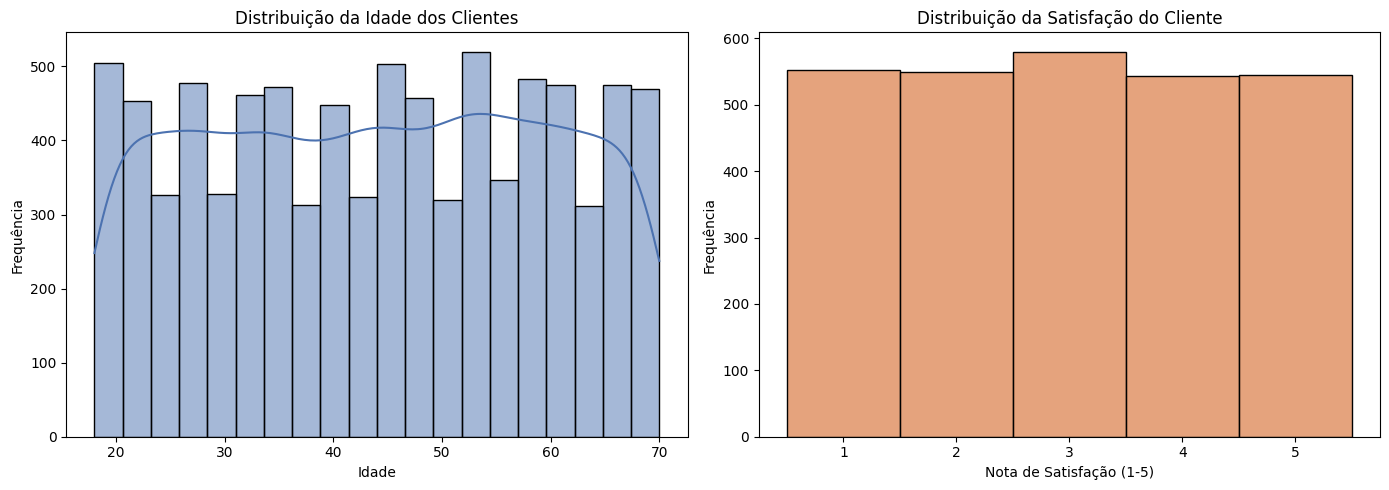

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(cs_df_limpo["Customer Age"], bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição da Idade dos Clientes")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")

sns.histplot(cs_df_limpo["Customer Satisfaction Rating"].dropna(), bins=5, discrete=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribuição da Satisfação do Cliente")
axes[1].set_xlabel("Nota de Satisfação (1-5)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [17]:
cs_df_limpo[["Customer Age", "Customer Satisfaction Rating", "Tempo de Resolucao (horas)"]].describe()

,Customer Age,Customer Satisfaction Rating,Tempo de Resolucao (horas)
count,8469.000000,2769.000000,1404.000000
mean,44.026804,2.991333,7.577932
std,15.296112,1.407016,5.596637
min,18.000000,1.000000,0.000000
25%,31.000000,2.000000,3.000000
50%,44.000000,3.000000,6.341667
75%,57.000000,4.000000,11.354167
max,70.000000,5.000000,23.466667


### Variáveis categóricas

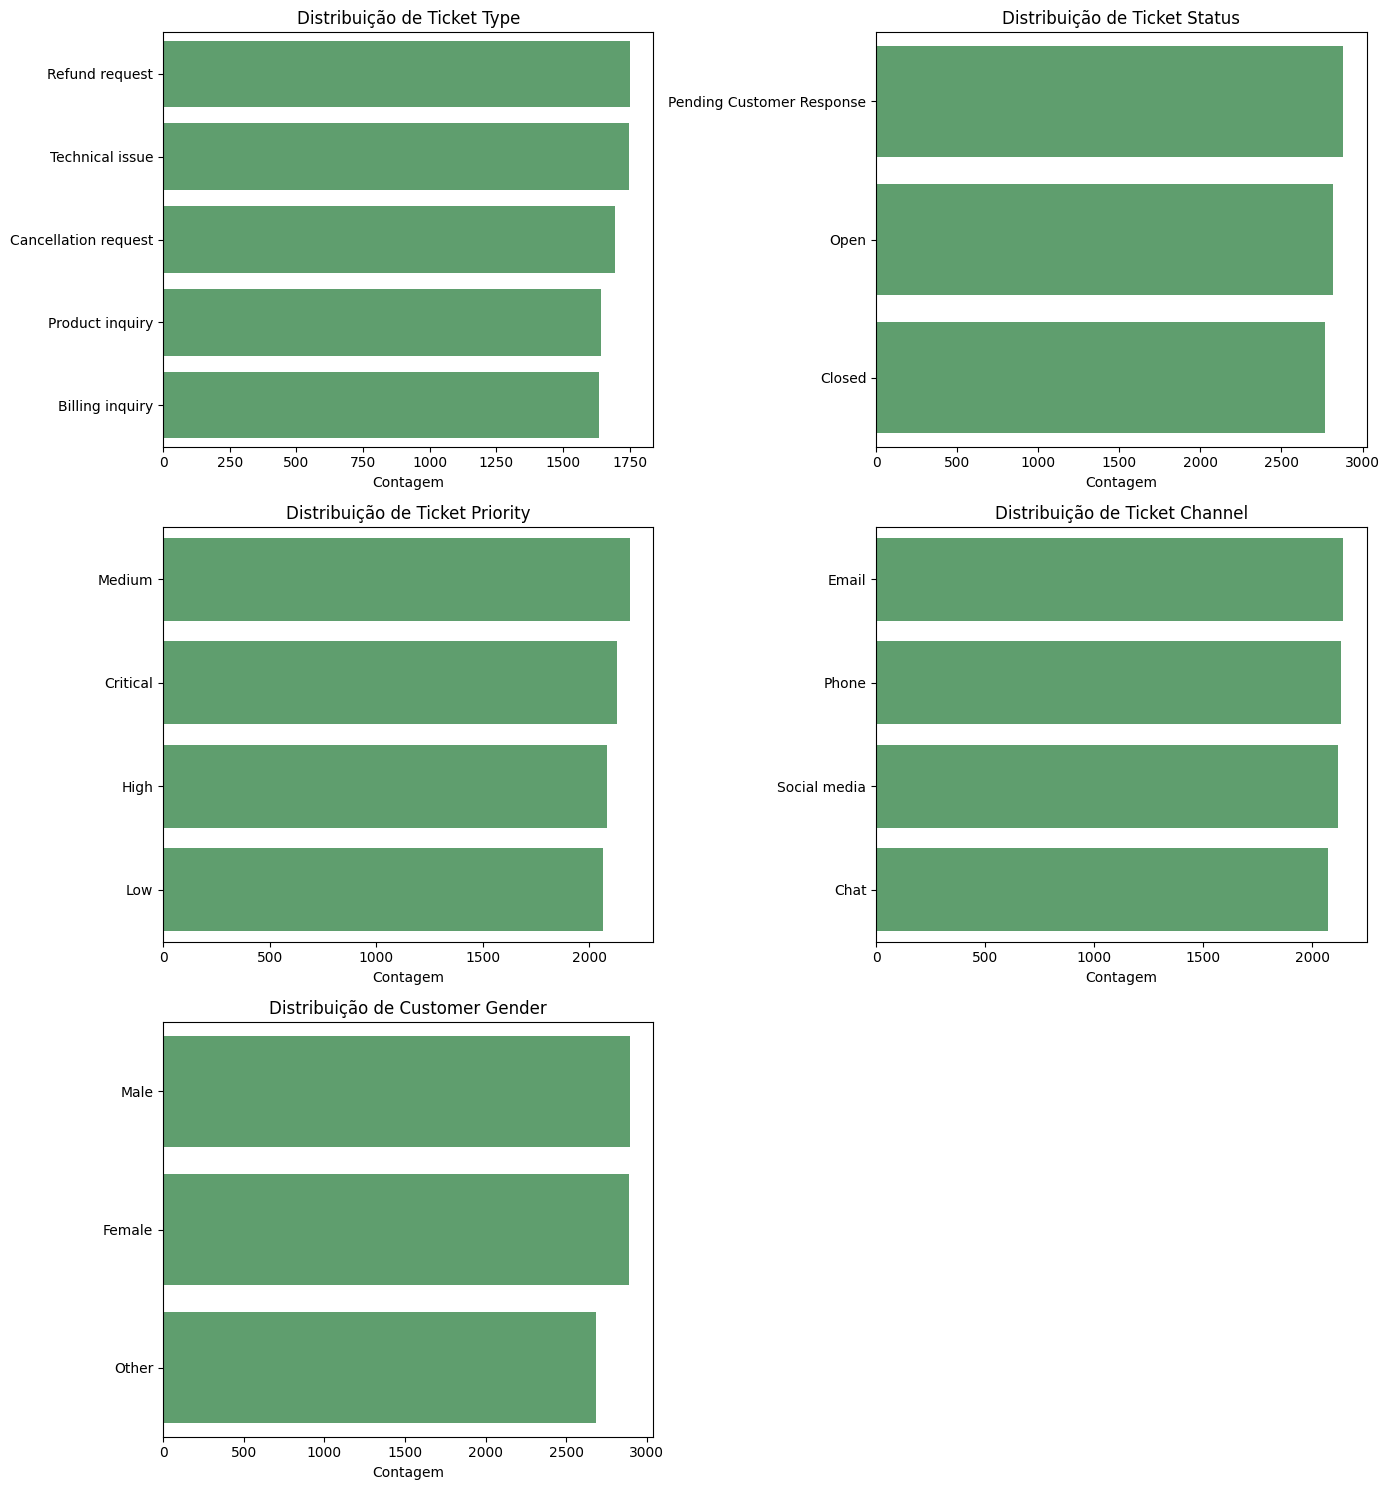

In [18]:
colunas_categoricas_analise = [
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel",
    "Customer Gender",
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for ax, coluna in zip(axes, colunas_categoricas_analise):
    ordem = cs_df_limpo[coluna].value_counts().index
    sns.countplot(data=cs_df_limpo, y=coluna, order=ordem, ax=ax, color="#55A868")
    ax.set_title(f"Distribuição de {coluna}")
    ax.set_xlabel("Contagem")
    ax.set_ylabel("")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

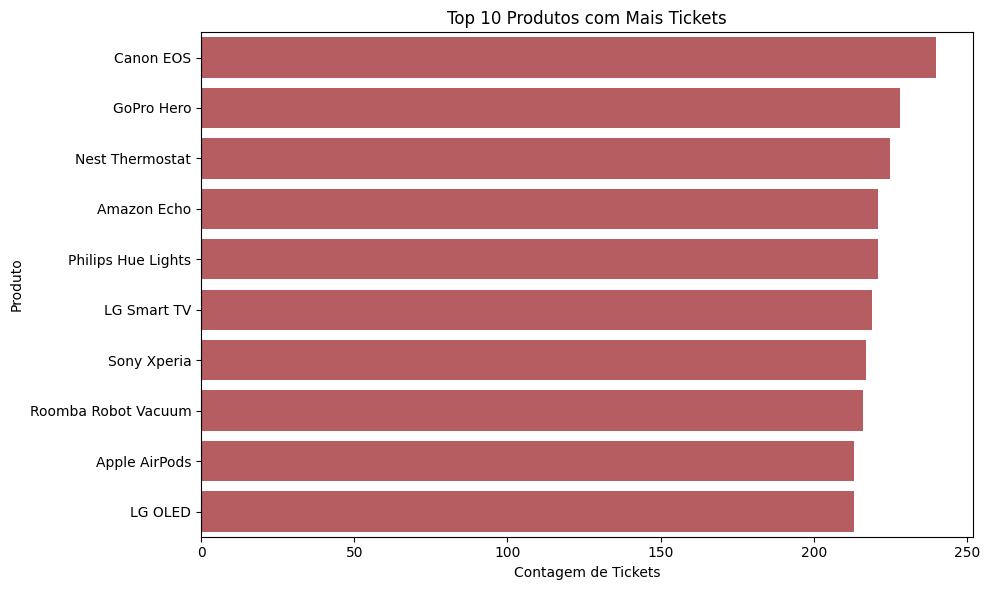

In [19]:
top_produtos = cs_df_limpo["Product Purchased"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_produtos.values, y=top_produtos.index, color="#C44E52")
plt.title("Top 10 Produtos com Mais Tickets")
plt.xlabel("Contagem de Tickets")
plt.ylabel("Produto")
plt.tight_layout()
plt.show()

In [20]:
for coluna in colunas_categoricas_analise:
    print(f"--- {coluna} ---")
    print(cs_df_limpo[coluna].value_counts(normalize=True).round(3) * 100)
    print()

--- Ticket Type ---
Ticket Type
Refund request          20.7
Technical issue         20.6
Cancellation request    20.0
Product inquiry         19.4
Billing inquiry         19.3
Name: proportion, dtype: float64

--- Ticket Status ---
Ticket Status
Pending Customer Response    34.0
Open                         33.3
Closed                       32.7
Name: proportion, dtype: float64

--- Ticket Priority ---
Ticket Priority
Medium      25.9
Critical    25.1
High        24.6
Low         24.4
Name: proportion, dtype: float64

--- Ticket Channel ---
Ticket Channel
Email           25.3
Phone           25.2
Social media    25.0
Chat            24.5
Name: proportion, dtype: float64

--- Customer Gender ---
Customer Gender
Male      34.2
Female    34.1
Other     31.7
Name: proportion, dtype: float64



### Variável textual

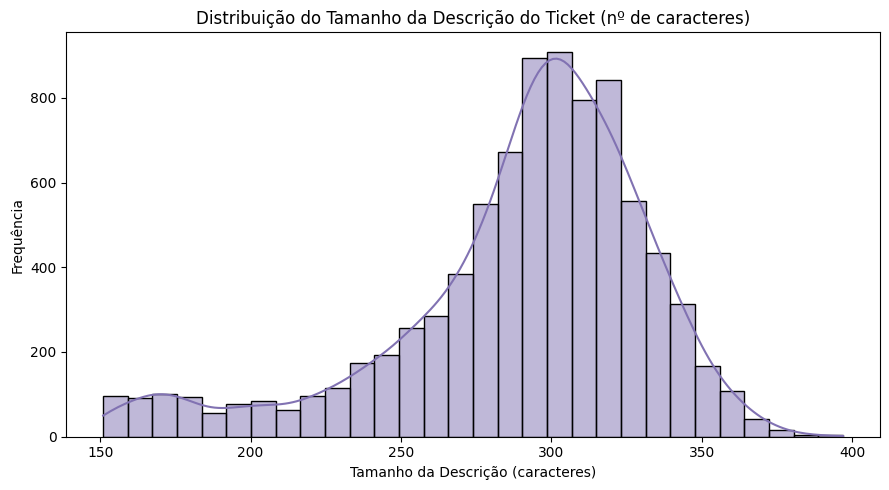

count    8469.000000
mean      289.821939
std        43.593954
min       151.000000
25%       273.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: Tamanho da Descricao, dtype: float64

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(cs_df_limpo["Tamanho da Descricao"].dropna(), bins=30, kde=True, color="#8172B2")
plt.title("Distribuição do Tamanho da Descrição do Ticket (nº de caracteres)")
plt.xlabel("Tamanho da Descrição (caracteres)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

cs_df_limpo["Tamanho da Descricao"].describe()

A Análise Univariada mostra os seguintes padrões:

- **`Customer Age`** apresenta distribuição aproximadamente uniforme entre 18 e 70 anos, sem concentração forte em nenhuma faixa etária específica.
- **`Customer Satisfaction Rating`** está distribuída de forma praticamente uniforme entre as notas 1 a 5.
- **`Ticket Type`**, **`Ticket Priority`**, **`Ticket Channel`** e **`Customer Gender`** estão bem distribuídos entre suas categorias, sem uma classe claramente dominante.
- **`Ticket Status`** mostra proporção relevante de tickets `Closed` frente a `Open`/`Pending Customer Response`.
- Entre os produtos, alguns aparelhos/eletrônicos concentram mais tickets do que outros.
- **`Tamanho da Descrição`** concentra a maior parte dos tickets entre 273 e 318 caracteres (intervalo interquartil), com uma cauda de descrições muito curtas (abaixo de ~205 caracteres), que será investigada na etapa de Outliers.

Essas distribuições relativamente equilibradas (quase uniformes) nas variáveis numéricas e categóricas reforçam o indício, já levantado no TP1, de que o *dataset* foi gerado/balanceado artificialmente. Essa observação é importante para os testes de hipótese a seguir: variáveis próximas de uma distribuição uniforme não atendem ao pressuposto de normalidade exigido pelo t-test, o que motiva o uso do teste não-paramétrico de Mann-Whitney.

## Formulação e Teste de Hipóteses

Como visto na Análise Univariada, `Customer Age` e `Customer Satisfaction Rating` seguem distribuições aproximadamente uniformes (não normais), e `Tempo de Resolução (horas)` é uma variável limitada e derivada de horários gerados sinteticamente. Por isso, optamos pelo teste não-paramétrico **Mann-Whitney U** em vez do t-test em todas as hipóteses abaixo: o Mann-Whitney compara a distribuição de duas amostras sem exigir normalidade, sendo mais adequado a este *dataset*. Em todos os testes, o nível de significância adotado é **α = 0.05**.

### Hipótese 1: Tempo de resolução por prioridade do ticket

**Contexto:** no TP1, a Hipótese 1 sugeriu que produtos mais complexos exigem mais suporte. Uma leitura análoga em nível de atendimento é: tickets de prioridade mais alta deveriam, em teoria, ser resolvidos mais rápido.

- **H0:** a distribuição do `Tempo de Resolução (horas)` é igual entre tickets `Critical` e `Low`.
- **H1:** a distribuição do `Tempo de Resolução (horas)` difere entre tickets `Critical` e `Low`.

n Critical = 374 | mediana = 5.98h
n Low      = 334 | mediana = 7.08h
Estatística U = 57612.50
p-valor = 0.0745


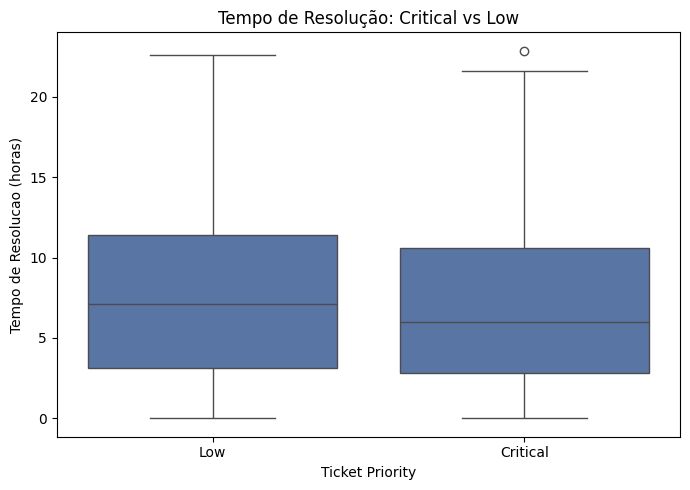

In [22]:
grupo_critical = cs_df_limpo.loc[cs_df_limpo["Ticket Priority"] == "Critical", "Tempo de Resolucao (horas)"].dropna()
grupo_low = cs_df_limpo.loc[cs_df_limpo["Ticket Priority"] == "Low", "Tempo de Resolucao (horas)"].dropna()

estatistica_h1, p_valor_h1 = mannwhitneyu(grupo_critical, grupo_low, alternative="two-sided")

print(f"n Critical = {len(grupo_critical)} | mediana = {grupo_critical.median():.2f}h")
print(f"n Low      = {len(grupo_low)} | mediana = {grupo_low.median():.2f}h")
print(f"Estatística U = {estatistica_h1:.2f}")
print(f"p-valor = {p_valor_h1:.4f}")

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=cs_df_limpo[cs_df_limpo["Ticket Priority"].isin(["Critical", "Low"])],
    x="Ticket Priority", y="Tempo de Resolucao (horas)", order=["Low", "Critical"], color="#4C72B0"
)
plt.title("Tempo de Resolução: Critical vs Low")
plt.tight_layout()
plt.show()

**Conclusão H1:** com p-valor = 0.0745 (> α = 0.05), **não rejeitamos H0**. Não há evidência estatística suficiente, ao nível de 5%, de que o tempo de resolução difira entre tickets `Critical` e `Low`, apesar da mediana do grupo `Critical` (5.98h) ser numericamente menor que a do grupo `Low` (7.08h). O resultado é coerente com o que já havia sido identificado na Verificação da Qualidade dos Dados: `First Response Time` e `Time to Resolution` são gerados de forma sintética, sem relação causal real com a prioridade do ticket.

### Hipótese 2: Idade do cliente e intenção de cancelamento/reembolso

**Contexto:** formalização estatística da Hipótese 2 do TP1 ("o comportamento de cancelamento e reembolso independe do perfil demográfico do cliente").

- **H0:** a distribuição de `Customer Age` é igual entre tickets do tipo `Cancellation request`/`Refund request` e os demais tipos.
- **H1:** a distribuição de `Customer Age` difere entre esses dois grupos.

n Cancelamento/Reembolso = 3447 | mediana = 44.0 anos
n Demais tipos           = 5022 | mediana = 44.0 anos
Estatística U = 8639660.50
p-valor = 0.8866


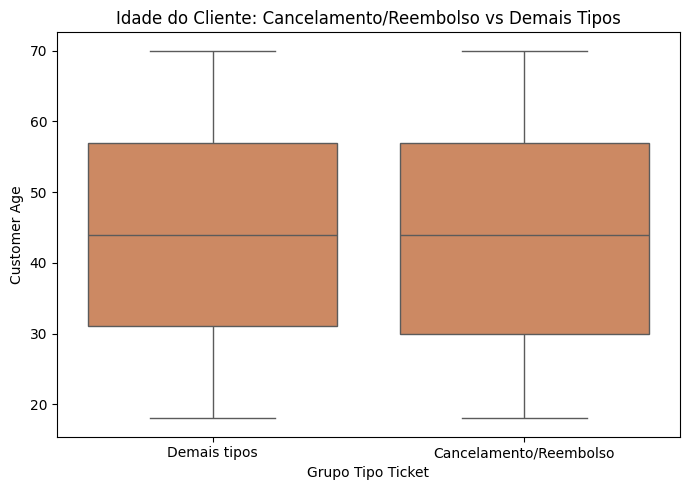

In [23]:
tipos_saida = ["Cancellation request", "Refund request"]
grupo_saida = cs_df_limpo.loc[cs_df_limpo["Ticket Type"].isin(tipos_saida), "Customer Age"]
grupo_outros = cs_df_limpo.loc[~cs_df_limpo["Ticket Type"].isin(tipos_saida), "Customer Age"]

estatistica_h2, p_valor_h2 = mannwhitneyu(grupo_saida, grupo_outros, alternative="two-sided")

print(f"n Cancelamento/Reembolso = {len(grupo_saida)} | mediana = {grupo_saida.median():.1f} anos")
print(f"n Demais tipos           = {len(grupo_outros)} | mediana = {grupo_outros.median():.1f} anos")
print(f"Estatística U = {estatistica_h2:.2f}")
print(f"p-valor = {p_valor_h2:.4f}")

plt.figure(figsize=(7, 5))
cs_df_limpo["Grupo Tipo Ticket"] = cs_df_limpo["Ticket Type"].isin(tipos_saida).map(
    {True: "Cancelamento/Reembolso", False: "Demais tipos"}
)
sns.boxplot(data=cs_df_limpo, x="Grupo Tipo Ticket", y="Customer Age", color="#DD8452")
plt.title("Idade do Cliente: Cancelamento/Reembolso vs Demais Tipos")
plt.tight_layout()
plt.show()

**Conclusão H2:** com p-valor = 0.8866 (>> α = 0.05), **não rejeitamos H0**. As medianas de idade são idênticas (44 anos) entre os dois grupos, confirmando estatisticamente a hipótese qualitativa do TP1: a intenção de cancelar um serviço ou pedir reembolso não está associada à idade do cliente.

### Hipótese 3: Canal de atendimento e satisfação do cliente

**Contexto:** formalização estatística da Hipótese 3 do TP1 sobre continuidade do atendimento. Aqui testamos se o *canal* de contato (que molda a experiência de atendimento) se traduz em diferença de satisfação percebida.

- **H0:** a distribuição de `Customer Satisfaction Rating` é igual entre os canais `Chat` e `Email`.
- **H1:** a distribuição de `Customer Satisfaction Rating` difere entre `Chat` e `Email`.

n Chat  = 674 | mediana = 3.0
n Email = 720 | mediana = 3.0
Estatística U = 254196.00
p-valor = 0.1164


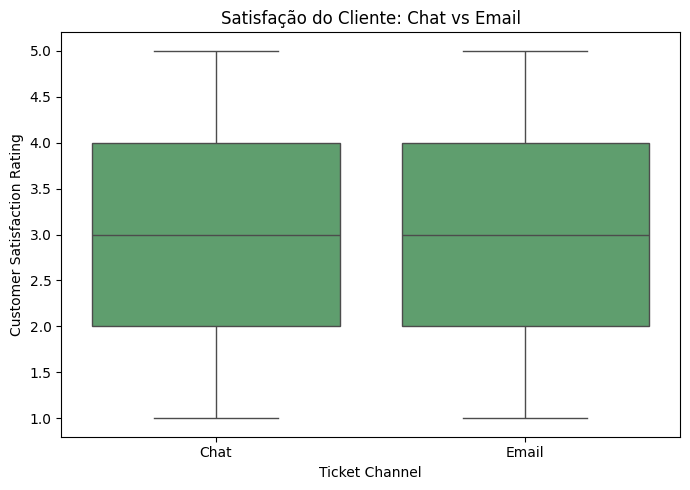

In [24]:
grupo_chat = cs_df_limpo.loc[cs_df_limpo["Ticket Channel"] == "Chat", "Customer Satisfaction Rating"].dropna()
grupo_email = cs_df_limpo.loc[cs_df_limpo["Ticket Channel"] == "Email", "Customer Satisfaction Rating"].dropna()

estatistica_h3, p_valor_h3 = mannwhitneyu(grupo_chat, grupo_email, alternative="two-sided")

print(f"n Chat  = {len(grupo_chat)} | mediana = {grupo_chat.median():.1f}")
print(f"n Email = {len(grupo_email)} | mediana = {grupo_email.median():.1f}")
print(f"Estatística U = {estatistica_h3:.2f}")
print(f"p-valor = {p_valor_h3:.4f}")

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=cs_df_limpo[cs_df_limpo["Ticket Channel"].isin(["Chat", "Email"])],
    x="Ticket Channel", y="Customer Satisfaction Rating", color="#55A868"
)
plt.title("Satisfação do Cliente: Chat vs Email")
plt.tight_layout()
plt.show()

**Conclusão H3:** com p-valor = 0.1164 (> α = 0.05), **não rejeitamos H0**. Não há diferença estatisticamente significativa na satisfação do cliente entre os canais `Chat` e `Email`, e ambos apresentam mediana igual a 3.

## 1.6. Análise Multivariada

### Correlação entre variáveis numéricas

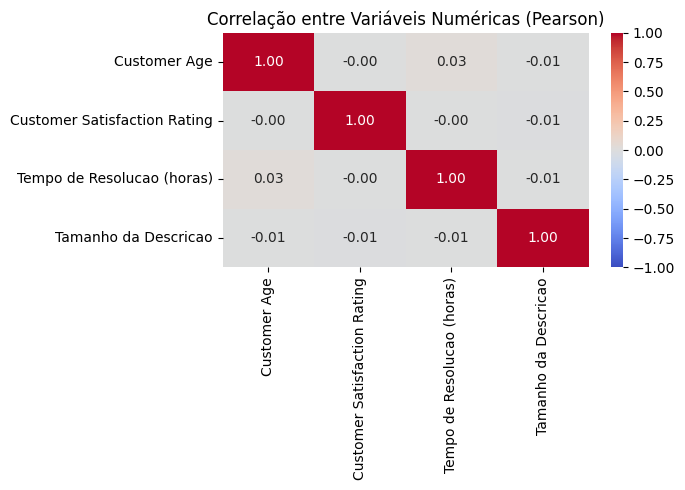

,Customer Age,Customer Satisfaction Rating,Tempo de Resolucao (horas),Tamanho da Descricao
Customer Age,1.000,-0.004,0.031,-0.006
Customer Satisfaction Rating,-0.004,1.000,-0.004,-0.014
Tempo de Resolucao (horas),0.031,-0.004,1.000,-0.006
Tamanho da Descricao,-0.006,-0.014,-0.006,1.000


In [25]:
colunas_numericas = ["Customer Age", "Customer Satisfaction Rating", "Tempo de Resolucao (horas)", "Tamanho da Descricao"]
correlacao = cs_df_limpo[colunas_numericas].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlação entre Variáveis Numéricas (Pearson)")
plt.tight_layout()
plt.show()

correlacao.round(3)

### Relação entre Tipo e Prioridade do Ticket

In [26]:
tabela_contingencia = pd.crosstab(cs_df_limpo["Ticket Type"], cs_df_limpo["Ticket Priority"])
chi2_stat, p_valor_chi2, graus_liberdade, esperado = chi2_contingency(tabela_contingencia)

print(f"Chi² = {chi2_stat:.2f} | graus de liberdade = {graus_liberdade} | p-valor = {p_valor_chi2:.4f}")
tabela_contingencia

Chi² = 10.63 | graus de liberdade = 12 | p-valor = 0.5613


Ticket Priority,Critical,High,Low,Medium
Ticket Type,,,,
Billing inquiry,420,382,398,434
Cancellation request,423,398,414,460
Product inquiry,403,399,398,441
Refund request,444,448,440,420
Technical issue,439,458,413,437


### Tempo de resolução por prioridade e satisfação por canal

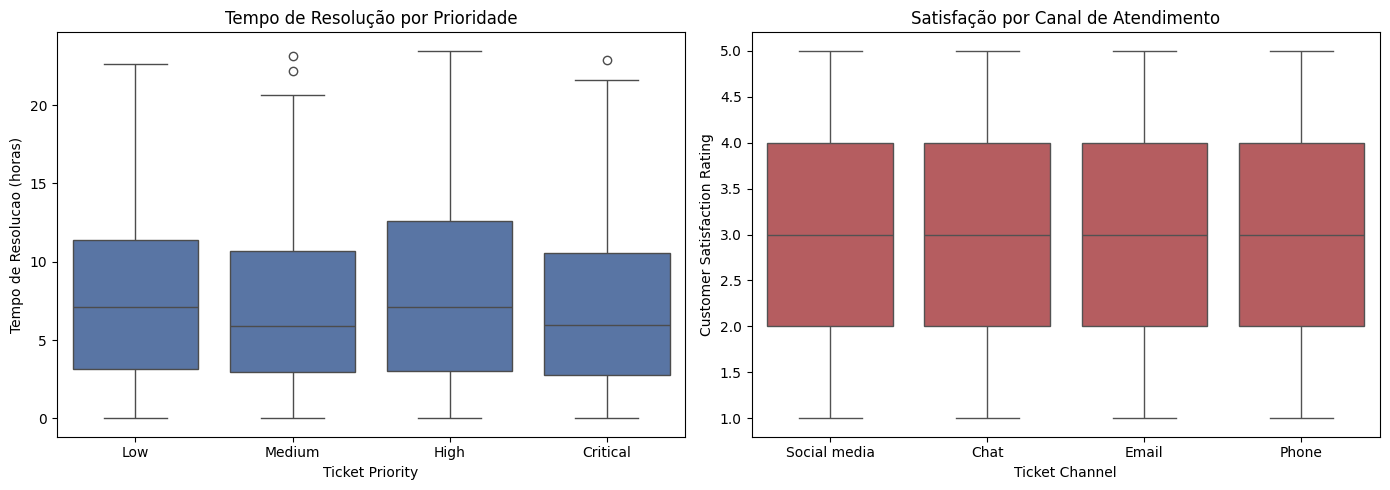

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem_prioridade = ["Low", "Medium", "High", "Critical"]
sns.boxplot(data=cs_df_limpo, x="Ticket Priority", y="Tempo de Resolucao (horas)", order=ordem_prioridade, ax=axes[0], color="#4C72B0")
axes[0].set_title("Tempo de Resolução por Prioridade")

sns.boxplot(data=cs_df_limpo, x="Ticket Channel", y="Customer Satisfaction Rating", ax=axes[1], color="#C44E52")
axes[1].set_title("Satisfação por Canal de Atendimento")

plt.tight_layout()
plt.show()

A Análise Multivariada mostra os seguintes padrões:

- **Correlação entre numéricas praticamente nula**: todos os coeficientes de Pearson entre `Customer Age`, `Customer Satisfaction Rating`, `Tempo de Resolução (horas)` e `Tamanho da Descrição` estão entre -0.014 e 0.031. Não há relação linear detectável entre nenhum par dessas variáveis.
- **`Ticket Type` x `Ticket Priority` não são associados**: o teste Chi² (χ² = 10.63, p = 0.5613, gl = 12) não rejeita a hipótese de independência. A prioridade de um ticket parece ser atribuída de forma independente do seu tipo/assunto.
- Os boxplots de `Tempo de Resolução` por prioridade e de `Satisfação` por canal mostram medianas e dispersões muito semelhantes entre os grupos, visualmente consistentes com os testes de hipótese da seção anterior (nenhum resultado estatisticamente significativo).

Em conjunto, esses resultados reforçam a conclusão já indicada na Análise Univariada: as variáveis estruturadas (numéricas e categóricas) deste *dataset* comportam-se de forma praticamente independente entre si, um padrão compatível com um conjunto de dados gerado/balanceado artificialmente. Isso tem uma implicação prática importante para o sistema de IA do projeto: o sinal relevante para prever a *intenção* do cliente provavelmente está concentrado na variável textual (`Ticket Description`, `Ticket Subject`), e não nos metadados estruturados do ticket.

## 1.7. Identificação de Outliers e Anomalias

In [28]:
def detectar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    return outliers, limite_inferior, limite_superior

colunas_outliers = ["Customer Age", "Tempo de Resolucao (horas)", "Tamanho da Descricao"]

for coluna in colunas_outliers:
    outliers, limite_inferior, limite_superior = detectar_outliers_iqr(cs_df_limpo[coluna].dropna())
    print(f"{coluna}:")
    print(f"  Limites (IQR): [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"  Mínimo/Máximo observado: [{cs_df_limpo[coluna].min():.2f}, {cs_df_limpo[coluna].max():.2f}]")
    print(f"  Nº de outliers: {len(outliers)} ({len(outliers) / cs_df_limpo[coluna].dropna().shape[0] * 100:.1f}% da coluna)")
    print()

Customer Age:
  Limites (IQR): [-8.00, 96.00]
  Mínimo/Máximo observado: [18.00, 70.00]
  Nº de outliers: 0 (0.0% da coluna)

Tempo de Resolucao (horas):
  Limites (IQR): [-9.53, 23.89]
  Mínimo/Máximo observado: [0.00, 23.47]
  Nº de outliers: 0 (0.0% da coluna)

Tamanho da Descricao:
  Limites (IQR): [205.50, 385.50]
  Mínimo/Máximo observado: [151.00, 397.00]
  Nº de outliers: 579 (6.8% da coluna)



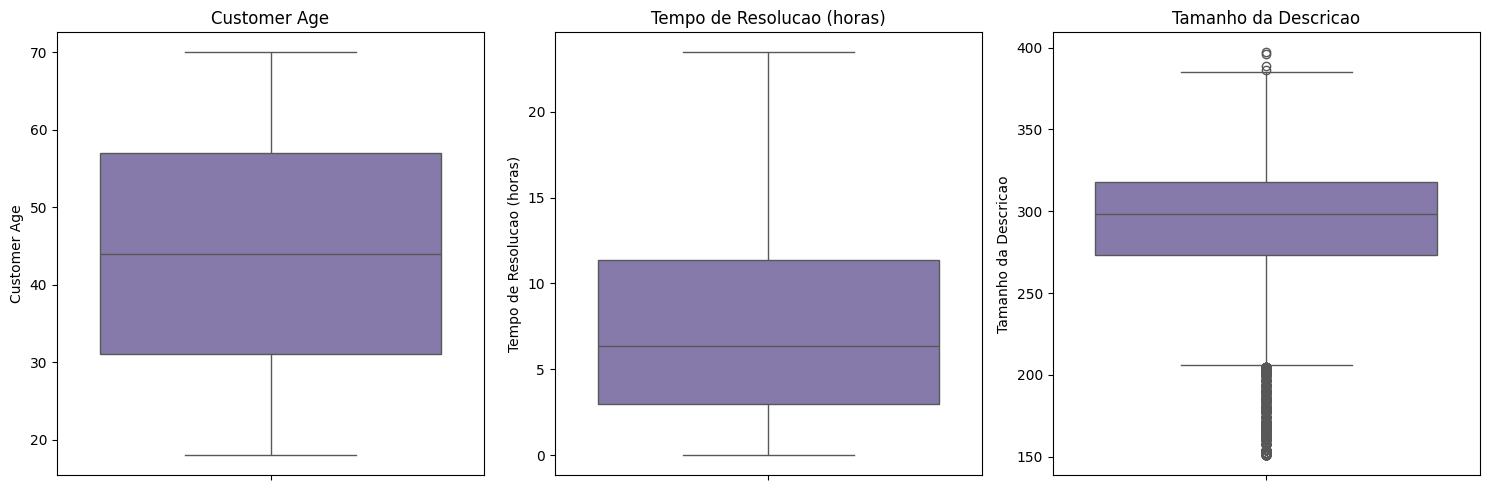

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, coluna in zip(axes, colunas_outliers):
    sns.boxplot(y=cs_df_limpo[coluna], ax=ax, color="#8172B2")
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

In [30]:
outliers_descricao, li_desc, ls_desc = detectar_outliers_iqr(cs_df_limpo["Tamanho da Descricao"].dropna())
cs_df_limpo.loc[outliers_descricao.index, ["Ticket Type", "Ticket Priority", "Tamanho da Descricao"]].head(10)

,Ticket Type,Ticket Priority,Tamanho da Descricao
23,Technical issue,Low,205
29,Cancellation request,Medium,203
52,Refund request,High,167
56,Technical issue,Medium,184
80,Technical issue,Critical,197
105,Product inquiry,Critical,151
106,Cancellation request,Low,152
107,Technical issue,High,165
189,Technical issue,Critical,190
207,Billing inquiry,Critical,174


A análise de outliers pelo método do Intervalo Interquartil (IQR, 1.5×IQR) mostra:

- **`Customer Age`**: 0 outliers. Os valores observados (18 a 70 anos) já estão dentro dos limites teóricos do IQR (-8 a 96), ou seja, a idade dos clientes é uma variável bem-comportada, sem valores atípicos.
- **`Tempo de Resolução (horas)`**: 0 outliers. Por construção, essa variável é limitada (diferença entre dois horários dentro do mesmo dia sintético, com negativos já removidos na limpeza), então não há tempos extremos a detectar. Isso reforça, mais uma vez, a natureza artificial dessa coluna.
- **`Tamanho da Descrição`**: **579 outliers** (~6.8% das descrições). Quase todos (**575**) estão *abaixo* do limite inferior (~205 caracteres), ou seja, são descrições muito curtas; apenas **4** ficam acima do limite superior (~385 caracteres). Essa é a única anomalia real e informativa do dataset. Os outliers se distribuem de forma proporcional entre `Ticket Type` e `Ticket Priority` (nenhum tipo ou prioridade concentra mais outliers do que sua participação no dataset), indicando que descrições curtas não são um problema específico de uma categoria. Para a etapa de modelagem, vale tratar `Tamanho da Descrição` como *feature* candidata: descrições muito curtas tendem a trazer pouca informação para classificar a intenção do cliente, o que pode afetar o modelo.

## 1.8. Documentação do EDA e Conclusões

**Resumo do dataset:** 8469 tickets de suporte ao cliente, 17 colunas originais (numéricas, categóricas e uma variável textual livre: `Ticket Description`), sem linhas duplicadas. O dataset é sintético/anonimizado (e-mails gerados, datas de resposta/resolução sem relação causal real), o que foi identificado na Verificação de Qualidade e confirmado repetidamente ao longo das análises seguintes.

**Qualidade e limpeza:** os nulos em `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` são estruturais (tickets ainda não fechados) e foram preservados, não imputados. Foram criadas três colunas auxiliares (`Ticket Resolvido`, `Tempo de Resolução (horas)`, `Tamanho da Descrição`) para viabilizar as análises seguintes, e 1365 durações negativas (artefato da geração sintética de horários) foram convertidas para ausente.

**Univariada:** as variáveis numéricas (`Customer Age`, `Customer Satisfaction Rating`) e a maioria das categóricas (`Ticket Type`, `Ticket Priority`, `Ticket Channel`, `Customer Gender`) mostram distribuições próximas da uniforme, sem classes dominantes, o que é um forte indício de dataset balanceado artificialmente. `Tamanho da Descrição` concentra-se entre 273 e 318 caracteres (intervalo interquartil), com cauda de descrições muito curtas.

**Testes de hipótese (Mann-Whitney, α = 0.05):** nenhuma das três hipóteses testadas foi estatisticamente significativa: tempo de resolução não difere por prioridade (p=0.0745), idade não difere entre tickets de cancelamento/reembolso e os demais (p=0.8866), e satisfação não difere entre os canais Chat e Email (p=0.1164). Isso é consistente, não contraditório: reforça que as variáveis estruturadas do dataset são, em grande parte, geradas de forma independente entre si.

**Multivariada:** correlações de Pearson entre todas as variáveis numéricas são próximas de zero (entre -0.014 e 0.031), e o teste Chi² não encontra associação entre `Ticket Type` e `Ticket Priority` (p=0.5613). Não há, portanto, relações estruturadas fortes a explorar entre os metadados do ticket.

**Outliers:** `Customer Age` e `Tempo de Resolução` não apresentam outliers pelo critério IQR: são variáveis limitadas por natureza/construção. `Tamanho da Descrição` tem 579 outliers (575 descrições muito curtas e 4 muito longas), a única anomalia real identificada no dataset, distribuídos de forma proporcional entre tipos e prioridades de ticket.

**Conclusão geral e próximos passos:** de forma consistente entre univariada, testes de hipótese, multivariada e outliers, este dataset se comporta como um conjunto **sintético e balanceado**, no qual os atributos estruturados (idade, canal, prioridade, tipo) carregam pouco ou nenhum sinal estatístico entre si ou em relação a tempo de resolução/satisfação. A implicação prática para o restante do bloco é que o modelo de classificação de intenção a ser construído deve se apoiar principalmente no **texto livre** (`Ticket Description` e `Ticket Subject`), com as variáveis estruturadas servindo, no máximo, como *features* auxiliares de baixo peso, e não como preditores fortes isolados.